In [1]:
import pandas as pd

df = pd.read_csv("WPI_2026.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 3807
Columns: 109


In [2]:
print(df.head())

   OID_  World Port Index Number                    Region Name  \
0   0.0                   7950.0  United States E Coast -- 6585   
1   1.0                  47620.0            Madagascar -- 47350   
2   2.0                  47020.0              Tanzania -- 46965   
3   3.0                  47005.0              Tanzania -- 46965   
4   4.0                  44804.0           Turkey Asia -- 44360   

      Main Port Name Alternate Port Name UN/LOCODE   Country Code  \
0             Maurer                                United States   
1            Iharana                                   Madagascar   
2        Chake Chake                                     Tanzania   
3  Mjimwema Terminal                                     Tanzania   
4     Delta Terminal                                       Turkey   

                          World Water Body IHO S-130 Sea Area  \
0                     North Atlantic Ocean                      
1                             Indian Ocean          

In [3]:
print(df.columns.tolist())

['OID_', 'World Port Index Number', 'Region Name', 'Main Port Name', 'Alternate Port Name', 'UN/LOCODE', 'Country Code', 'World Water Body', 'IHO S-130 Sea Area', 'Sailing Direction or Publication', 'Publication Link', 'Standard Nautical Chart', 'IHO S-57 Electronic Navigational Chart', 'IHO S-101 Electronic Navigational Chart', 'Digital Nautical Chart', 'Tidal Range (m)', 'Entrance Width (m)', 'Channel Depth (m)', 'Anchorage Depth (m)', 'Cargo Pier Depth (m)', 'Oil Terminal Depth (m)', 'Liquified Natural Gas Terminal Depth (m)', 'Maximum Vessel Length (m)', 'Maximum Vessel Beam (m)', 'Maximum Vessel Draft (m)', 'Offshore Maximum Vessel Length (m)', 'Offshore Maximum Vessel Beam (m)', 'Offshore Maximum Vessel Draft (m)', 'Harbor Size', 'Harbor Type', 'Harbor Use', 'Shelter Afforded', 'Entrance Restriction - Tide', 'Entrance Restriction - Heavy Swell', 'Entrance Restriction - Ice', 'Entrance Restriction - Other', 'Overhead Limits', 'Underkeel Clearance Management System', 'Good Holding 

# Feature engineering 

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3807 entries, 0 to 3806
Columns: 109 entries, OID_ to Longitude
dtypes: float64(17), object(92)
memory usage: 3.2+ MB
None


In [5]:
for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

1 : OID_
2 : World Port Index Number
3 : Region Name
4 : Main Port Name
5 : Alternate Port Name
6 : UN/LOCODE
7 : Country Code
8 : World Water Body
9 : IHO S-130 Sea Area
10 : Sailing Direction or Publication
11 : Publication Link
12 : Standard Nautical Chart
13 : IHO S-57 Electronic Navigational Chart
14 : IHO S-101 Electronic Navigational Chart
15 : Digital Nautical Chart
16 : Tidal Range (m)
17 : Entrance Width (m)
18 : Channel Depth (m)
19 : Anchorage Depth (m)
20 : Cargo Pier Depth (m)
21 : Oil Terminal Depth (m)
22 : Liquified Natural Gas Terminal Depth (m)
23 : Maximum Vessel Length (m)
24 : Maximum Vessel Beam (m)
25 : Maximum Vessel Draft (m)
26 : Offshore Maximum Vessel Length (m)
27 : Offshore Maximum Vessel Beam (m)
28 : Offshore Maximum Vessel Draft (m)
29 : Harbor Size
30 : Harbor Type
31 : Harbor Use
32 : Shelter Afforded
33 : Entrance Restriction - Tide
34 : Entrance Restriction - Heavy Swell
35 : Entrance Restriction - Ice
36 : Entrance Restriction - Other
37 : Overhea

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)
print("columns with missing values:")
print("missing")

columns with missing values:
missing


In [7]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 484


In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Repairs                                  304
Dry Dock                                  77
Railway                                   40
Shelter Afforded                          35
Underkeel Clearance Management System     28
dtype: int64


In [9]:
df = df.fillna("Unknown")

print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [11]:
duplicate_ports = df["Main Port Name"].duplicated().sum()

print("Duplicate port names:", duplicate_ports)


Duplicate port names: 90


In [12]:
duplicate_locode = df["UN/LOCODE"].duplicated().sum()

print("Duplicate UN/LOCODE:", duplicate_locode)

Duplicate UN/LOCODE: 478


In [13]:
duplicate_rows = df.duplicated().sum()

print("Completely duplicate rows:", duplicate_rows)

Completely duplicate rows: 0


In [14]:
duplicate_locodes = df[df["UN/LOCODE"].duplicated(keep=False)]

print("Rows with duplicate UN/LOCODE:", len(duplicate_locodes))

duplicate_locodes[
    ["UN/LOCODE", "Main Port Name", "Country Code", "Latitude", "Longitude"]
].sort_values("UN/LOCODE").head(30)

Rows with duplicate UN/LOCODE: 499


,UN/LOCODE,Main Port Name,Country Code,Latitude,Longitude
0,,Maurer,United States,40.533333,-74.250000
2358,,Port Ashton,United States,60.066667,-148.050000
2355,,Tranneset,Norway,60.416667,5.016667
2353,,Rose Inlet,United States,54.950000,-132.966667
2351,,Waubaushene,Canada,44.766667,-79.716667
2349,,Rockport,United States,45.200000,-83.383333
2344,,Port Chilkoot,United States,59.233333,-135.433333
2328,,Porpoise Harbor,Canada,54.216667,-130.283333
2323,,Port Severn,Canada,44.800000,-79.716667
2320,,Unga,United States,55.183333,-160.500000


In [15]:
duplicate_locodes = (
    df[df["UN/LOCODE"].duplicated(keep=False)]
    .sort_values("UN/LOCODE")
)

print(
    duplicate_locodes[
        [
            "UN/LOCODE",
            "Main Port Name",
            "Country Code",
            "Latitude",
            "Longitude"
        ]
    ].head(50).to_string(index=False)
)

UN/LOCODE       Main Port Name   Country Code   Latitude   Longitude
                        Maurer  United States  40.533333  -74.250000
                   Port Ashton  United States  60.066667 -148.050000
                     Tranneset         Norway  60.416667    5.016667
                    Rose Inlet  United States  54.950000 -132.966667
                   Waubaushene         Canada  44.766667  -79.716667
                      Rockport  United States  45.200000  -83.383333
                 Port Chilkoot  United States  59.233333 -135.433333
               Porpoise Harbor         Canada  54.216667 -130.283333
                   Port Severn         Canada  44.800000  -79.716667
                          Unga  United States  55.183333 -160.500000
                   Port Hobron  United States  57.166667 -153.166667
               Port Conclusion  United States  56.250000 -134.683333
                    Signilskar        Finland  60.200000   19.333333
                      Sointula    

In [16]:
unique_port_locations = df[
    ["UN/LOCODE", "Latitude", "Longitude"]
].drop_duplicates()

print("Original rows:", len(df))
print("Unique UN/LOCODE + coordinates:", len(unique_port_locations))

Original rows: 3807
Unique UN/LOCODE + coordinates: 3806


In [17]:
duplicate_location = df[
    df.duplicated(
        subset=["UN/LOCODE", "Latitude", "Longitude"],
        keep=False
    )
]

print(duplicate_location[
    ["UN/LOCODE", "Main Port Name", "Country Code", "Latitude", "Longitude"]
].to_string(index=False))

UN/LOCODE   Main Port Name  Country Code  Latitude  Longitude
          Tompkinsville SI United States 40.633333 -74.066667
              Stapleton SI United States 40.633333 -74.066667


In [18]:


print(df[
    [
        "Main Port Name",
        "UN/LOCODE",
        "Country Code",
        "Latitude",
        "Longitude",
        "Channel Depth (m)",
        "Anchorage Depth (m)",
        "Maximum Vessel Length (m)",
        "Maximum Vessel Beam (m)",
        "Maximum Vessel Draft (m)"
    ]
].dtypes)

Main Port Name                object
UN/LOCODE                     object
Country Code                  object
Latitude                     float64
Longitude                    float64
Channel Depth (m)            float64
Anchorage Depth (m)          float64
Maximum Vessel Length (m)    float64
Maximum Vessel Beam (m)      float64
Maximum Vessel Draft (m)     float64
dtype: object


In [19]:


port_columns = [
    "World Port Index Number",
    "Region Name",
    "Main Port Name",
    "Alternate Port Name",
    "UN/LOCODE",
    "Country Code",
    "World Water Body",
    "IHO S-130 Sea Area",

    "Latitude",
    "Longitude",

    "Tidal Range (m)",
    "Entrance Width (m)",
    "Channel Depth (m)",
    "Anchorage Depth (m)",
    "Cargo Pier Depth (m)",

    "Maximum Vessel Length (m)",
    "Maximum Vessel Beam (m)",
    "Maximum Vessel Draft (m)",

    "Harbor Size",
    "Harbor Type",
    "Harbor Use",
    "Shelter Afforded",

    "Entrance Restriction - Tide",
    "Entrance Restriction - Heavy Swell",
    "Entrance Restriction - Ice",
    "Entrance Restriction - Other",
    "Overhead Limits",

    "Underkeel Clearance Management System",
    "Good Holding Ground",
    "Turning Area",

    "Port Security",
    "Traffic Separation Scheme",
    "Vessel Traffic Service",

    "Pilotage - Compulsory",
    "Pilotage - Available"
]

In [20]:
ports_master = df[port_columns].copy()

print("Rows:", ports_master.shape[0])
print("Columns:", ports_master.shape[1])

Rows: 3807
Columns: 35


In [21]:
print(ports_master.head())

   World Port Index Number                    Region Name     Main Port Name  \
0                   7950.0  United States E Coast -- 6585             Maurer   
1                  47620.0            Madagascar -- 47350            Iharana   
2                  47020.0              Tanzania -- 46965        Chake Chake   
3                  47005.0              Tanzania -- 46965  Mjimwema Terminal   
4                  44804.0           Turkey Asia -- 44360     Delta Terminal   

  Alternate Port Name UN/LOCODE   Country Code  \
0                                United States   
1                                   Madagascar   
2                                     Tanzania   
3                                     Tanzania   
4                                       Turkey   

                          World Water Body IHO S-130 Sea Area   Latitude  \
0                     North Atlantic Ocean                     40.533333   
1                             Indian Ocean                    -13.

In [22]:
print(ports_master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3807 entries, 0 to 3806
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   World Port Index Number                3807 non-null   float64
 1   Region Name                            3807 non-null   object 
 2   Main Port Name                         3807 non-null   object 
 3   Alternate Port Name                    3807 non-null   object 
 4   UN/LOCODE                              3807 non-null   object 
 5   Country Code                           3807 non-null   object 
 6   World Water Body                       3807 non-null   object 
 7   IHO S-130 Sea Area                     3807 non-null   object 
 8   Latitude                               3807 non-null   float64
 9   Longitude                              3807 non-null   float64
 10  Tidal Range (m)                        3807 non-null   float64
 11  Entr

In [23]:
print("Shape:", ports_master.shape)

Shape: (3807, 35)


In [24]:
print("Rows:", len(ports_master))
print("Columns:", len(ports_master.columns))
print("Missing values:", ports_master.isnull().sum().sum())
print("Duplicate rows:", ports_master.duplicated().sum())

Rows: 3807
Columns: 35
Missing values: 0
Duplicate rows: 0


In [25]:
print("\nColumn names:")
for i, column in enumerate(ports_master.columns, start=1):
    print(i, ":", column)


Column names:
1 : World Port Index Number
2 : Region Name
3 : Main Port Name
4 : Alternate Port Name
5 : UN/LOCODE
6 : Country Code
7 : World Water Body
8 : IHO S-130 Sea Area
9 : Latitude
10 : Longitude
11 : Tidal Range (m)
12 : Entrance Width (m)
13 : Channel Depth (m)
14 : Anchorage Depth (m)
15 : Cargo Pier Depth (m)
16 : Maximum Vessel Length (m)
17 : Maximum Vessel Beam (m)
18 : Maximum Vessel Draft (m)
19 : Harbor Size
20 : Harbor Type
21 : Harbor Use
22 : Shelter Afforded
23 : Entrance Restriction - Tide
24 : Entrance Restriction - Heavy Swell
25 : Entrance Restriction - Ice
26 : Entrance Restriction - Other
27 : Overhead Limits
28 : Underkeel Clearance Management System
29 : Good Holding Ground
30 : Turning Area
31 : Port Security
32 : Traffic Separation Scheme
33 : Vessel Traffic Service
34 : Pilotage - Compulsory
35 : Pilotage - Available


In [26]:
ports_master.to_csv("ports_master.csv", index=False)

print("ports_master.csv created successfully!")

ports_master.csv created successfully!


In [27]:
import os

print("File exists:", os.path.exists("ports_master.csv"))
print("File size:", os.path.getsize("ports_master.csv"), "bytes")

File exists: True
File size: 1017726 bytes


#  MarineGuard AI — Waiting Time Prediction

## ADB Historical Port Traffic Data

This dataset contains historical port-operation data.

We will use it to:
- Understand port traffic
- Find waiting-time information
- Select ML features
- Build the Waiting-Time Prediction model

 This is historical data, not live data.

In [28]:
import pandas as pd

adb = pd.read_csv("ADB_port_traffic_data.csv")

print("Shape:", adb.shape)
print("\nColumns:")
print(adb.columns.tolist())

print("\nFirst 5 rows:")
display(adb.head())

print("\nMissing values:")
print(adb.isnull().sum())

Shape: (3991, 70)

Columns:
['Port', 'Year', 'Week', 'Month', 'count_entrance', 'numofcall', 'avgservice_time', 'avgwaiting_time', 'ma4_count_entrance', 'ma4_numofcall', 'ma4_avgservice_time', 'ma4_avgwaiting_time', 'ma8_count_entrance', 'ma8_numofcall', 'ma8_avgservice_time', 'ma8_avgwaiting_time', 'ma12_count_entrance', 'ma12_numofcall', 'ma12_avgservice_time', 'ma12_avgwaiting_time', 'count_entrance_feeder', 'numofcall_feeder', 'avgservice_time_feed', 'avgwaiting_time_feed', 'ma4_count_entrance_feeder', 'ma4_numofcall_feeder', 'ma4_avgservice_time_feeder', 'ma4_avgwaiting_time_feeder', 'ma8_count_entrance_feeder', 'ma8_numofcall_feeder', 'ma8_avgservice_time_feeder', 'ma8_avgwaiting_time_feeder', 'ma12_count_entrance_feeder', 'ma12_numofcall_feeder', 'ma12_avgservice_time_feeder', 'ma12_avgwaiting_time_feeder', 'count_entrance_intermediate', 'numofcall_intermediate', ' avgservice_time_intermediate ', ' avgwaiting_time_intermediate ', 'ma4_count_entrance_intermediate', 'ma4_numofcall

,Port,Year,Week,Month,count_entrance,numofcall,avgservice_time,avgwaiting_time,ma4_count_entrance,ma4_numofcall,...,ma8_count_entrance_neopanamax,ma8_numofcall_neopanamax,ma8_avgservice_time_neopanamax,ma8_avgwaiting_time_neopanamax,ma12_count_entrance_neopanamax,ma12_numofcall_neopanamax,ma12_avgservice_time_neopanamax,ma12_avgwaiting_time_neopanamax,share_neopan,country
0,Antwerp,2019.0,1.0,1.0,130.0,177.0,69.0,9.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,Belgium
1,Antwerp,2019.0,2.0,1.0,90.0,138.0,37.0,6.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,Belgium
2,Antwerp,2019.0,3.0,1.0,90.0,139.0,32.0,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.0,Belgium
3,Antwerp,2019.0,4.0,1.0,94.0,146.0,28.0,5.0,101.0,150.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,Belgium
4,Antwerp,2019.0,5.0,1.0,95.0,142.0,32.0,10.0,92.0,141.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,Belgium



Missing values:
Port                                 1
Year                                 1
Week                                 1
Month                                1
count_entrance                       1
                                  ... 
ma12_numofcall_neopanamax          210
ma12_avgservice_time_neopanamax    210
ma12_avgwaiting_time_neopanamax    210
share_neopan                         1
country                              1
Length: 70, dtype: int64


In [29]:
print("Total missing values:", adb.isnull().sum().sum())
print("\nMissing values per column:")
print(adb.isnull().sum().sort_values(ascending=False).head(20))

Total missing values: 6452

Missing values per column:
ma12_numofcall_feeder                210
ma12_avgservice_time_feeder          210
ma12_numofcall                       210
ma12_count_entrance                  210
ma12_avgwaiting_time                 210
ma12_avgservice_time                 210
ma12_avgservice_time_neopanamax      210
ma12_avgwaiting_time_neopanamax      210
ma12_count_entrance_neopanamax       210
ma12_numofcall_neopanamax            210
ma12_numofcall_intermediate          210
ma12_count_entrance_intermediate     210
ma12_count_entrance_feeder           210
ma12_avgservice_time_intermediate    210
ma12_avgwaiting_time_intermediate    210
ma12_avgwaiting_time_feeder          209
ma8_avgservice_time_intermediate     134
ma8_avgwaiting_time_intermediate     134
ma8_count_entrance_neopanamax        134
ma8_numofcall_neopanamax             134
dtype: int64


In [30]:
print("Missing target values:", adb["avgwaiting_time"].isnull().sum())
print("Total rows:", len(adb))

Missing target values: 1
Total rows: 3991


## Target Cleaning

`avgwaiting_time` is our target variable.

Only 1 record has a missing target value, so we will remove that record.

In [31]:
adb = adb.dropna(subset=["avgwaiting_time"]).copy()

print("Rows after removing missing target:", len(adb))
print("Missing target values:", adb["avgwaiting_time"].isnull().sum())

Rows after removing missing target: 3990
Missing target values: 0


In [32]:
# Find numerical columns
numeric_cols = adb.select_dtypes(include="number").columns

# Fill missing numerical feature values with column median
for col in numeric_cols:
    if col != "avgwaiting_time":
        adb[col] = adb[col].fillna(adb[col].median())

print("Total missing values:", adb.isnull().sum().sum())

Total missing values: 0


In [33]:
print(adb.isnull().sum()[adb.isnull().sum() > 0])

Series([], dtype: int64)


In [34]:
print("All columns:")
for i, col in enumerate(adb.columns, 1):
    print(i, col)

All columns:
1 Port
2 Year
3 Week
4 Month
5 count_entrance
6 numofcall
7 avgservice_time
8 avgwaiting_time
9 ma4_count_entrance
10 ma4_numofcall
11 ma4_avgservice_time
12 ma4_avgwaiting_time
13 ma8_count_entrance
14 ma8_numofcall
15 ma8_avgservice_time
16 ma8_avgwaiting_time
17 ma12_count_entrance
18 ma12_numofcall
19 ma12_avgservice_time
20 ma12_avgwaiting_time
21 count_entrance_feeder
22 numofcall_feeder
23 avgservice_time_feed
24 avgwaiting_time_feed
25 ma4_count_entrance_feeder
26 ma4_numofcall_feeder
27 ma4_avgservice_time_feeder
28 ma4_avgwaiting_time_feeder
29 ma8_count_entrance_feeder
30 ma8_numofcall_feeder
31 ma8_avgservice_time_feeder
32 ma8_avgwaiting_time_feeder
33 ma12_count_entrance_feeder
34 ma12_numofcall_feeder
35 ma12_avgservice_time_feeder
36 ma12_avgwaiting_time_feeder
37 count_entrance_intermediate
38 numofcall_intermediate
39  avgservice_time_intermediate 
40  avgwaiting_time_intermediate 
41 ma4_count_entrance_intermediate
42 ma4_numofcall_intermediate
43 ma4_av

In [35]:
print(adb["avgwaiting_time"].describe())

count    3990.000000
mean       12.686717
std        13.323674
min         0.000000
25%         6.000000
50%         9.000000
75%        15.000000
max       157.000000
Name: avgwaiting_time, dtype: float64


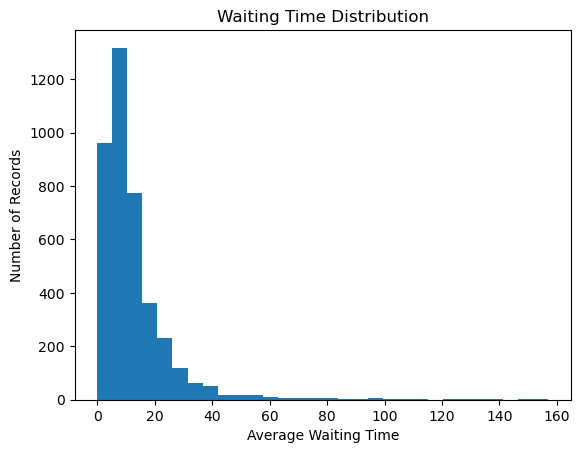

In [36]:
import matplotlib.pyplot as plt

plt.hist(adb["avgwaiting_time"], bins=30)
plt.xlabel("Average Waiting Time")
plt.ylabel("Number of Records")
plt.title("Waiting Time Distribution")
plt.show()

In [37]:
corr = adb.select_dtypes(include="number").corr()["avgwaiting_time"]
print(corr.sort_values(ascending=False).head(15))

avgwaiting_time                      1.000000
ma4_avgwaiting_time                  0.899125
 avgwaiting_time_intermediate        0.893585
ma4_avgwaiting_time_intermediate     0.839832
ma8_avgwaiting_time                  0.828140
avgwaiting_time_feed                 0.781983
ma4_avgwaiting_time_feeder           0.780698
ma12_avgwaiting_time                 0.778885
ma8_avgwaiting_time_intermediate     0.777020
avgwaiting_time_neopanamax           0.775934
ma8_avgwaiting_time_feeder           0.743125
ma12_avgwaiting_time_intermediate    0.734269
ma4_avgwaiting_time_neopanamax       0.722266
ma12_avgwaiting_time_feeder          0.685746
ma8_avgwaiting_time_neopanamax       0.680369
Name: avgwaiting_time, dtype: float64


In [38]:
print(adb[["Port", "Year", "Week", "Month"]].head(20))
print("\nYears:", sorted(adb["Year"].unique()))
print("\nNumber of ports:", adb["Port"].nunique())

       Port    Year  Week  Month
0   Antwerp  2019.0   1.0    1.0
1   Antwerp  2019.0   2.0    1.0
2   Antwerp  2019.0   3.0    1.0
3   Antwerp  2019.0   4.0    1.0
4   Antwerp  2019.0   5.0    1.0
5   Antwerp  2019.0   6.0    2.0
6   Antwerp  2019.0   7.0    2.0
7   Antwerp  2019.0   8.0    2.0
8   Antwerp  2019.0   9.0    2.0
9   Antwerp  2019.0  10.0    3.0
10  Antwerp  2019.0  11.0    3.0
11  Antwerp  2019.0  12.0    3.0
12  Antwerp  2019.0  13.0    3.0
13  Antwerp  2019.0  14.0    4.0
14  Antwerp  2019.0  15.0    4.0
15  Antwerp  2019.0  16.0    4.0
16  Antwerp  2019.0  17.0    4.0
17  Antwerp  2019.0  18.0    5.0
18  Antwerp  2019.0  19.0    5.0
19  Antwerp  2019.0  20.0    5.0

Years: [np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0)]

Number of ports: 19


In [39]:
print(adb[[
    "Port",
    "Week",
    "avgwaiting_time",
    "ma4_avgwaiting_time",
    "ma8_avgwaiting_time",
    "ma12_avgwaiting_time"
]].tail(15))

        Port  Week  avgwaiting_time  ma4_avgwaiting_time  ma8_avgwaiting_time  \
3975  Xiamen  38.0              5.0                  4.0                  6.0   
3976  Xiamen  39.0              6.0                  5.0                  6.0   
3977  Xiamen  40.0              1.0                  4.0                  5.0   
3978  Xiamen  41.0              6.0                  5.0                  5.0   
3979  Xiamen  42.0             11.0                  6.0                  5.0   
3980  Xiamen  43.0             11.0                  7.0                  6.0   
3981  Xiamen  44.0             11.0                 10.0                  7.0   
3982  Xiamen  45.0             16.0                 12.0                  9.0   
3983  Xiamen  46.0             17.0                 14.0                 10.0   
3984  Xiamen  47.0             12.0                 14.0                 11.0   
3985  Xiamen  48.0             10.0                 14.0                 12.0   
3986  Xiamen  49.0          

## Historical Waiting-Time Features

The MA4, MA8 and MA12 features represent historical waiting-time patterns.

They can help the model understand recent and longer-term congestion trends.

We will keep them as candidate features and verify their calculation before
final model training.

In [40]:
corr = adb.select_dtypes(include="number").corr()["avgwaiting_time"]

print(corr.sort_values(ascending=False).to_string())

avgwaiting_time                      1.000000
ma4_avgwaiting_time                  0.899125
 avgwaiting_time_intermediate        0.893585
ma4_avgwaiting_time_intermediate     0.839832
ma8_avgwaiting_time                  0.828140
avgwaiting_time_feed                 0.781983
ma4_avgwaiting_time_feeder           0.780698
ma12_avgwaiting_time                 0.778885
ma8_avgwaiting_time_intermediate     0.777020
avgwaiting_time_neopanamax           0.775934
ma8_avgwaiting_time_feeder           0.743125
ma12_avgwaiting_time_intermediate    0.734269
ma4_avgwaiting_time_neopanamax       0.722266
ma12_avgwaiting_time_feeder          0.685746
ma8_avgwaiting_time_neopanamax       0.680369
ma12_avgwaiting_time_neopanamax      0.649835
 avgservice_time_intermediate        0.406628
avgservice_time_neopanamax           0.403428
ma4_avgservice_time_intermediate     0.399507
ma4_avgservice_time_neopanamax       0.385873
avgservice_time                      0.381965
ma8_avgservice_time_intermediate  

In [41]:
features = [
    "Port", "Year", "Week", "Month",
    "count_entrance", "numofcall", "avgservice_time",
    
    "ma4_avgwaiting_time",
    "ma8_avgwaiting_time",
    "ma12_avgwaiting_time",
    
    "count_entrance_feeder",
    "numofcall_feeder",
    "avgservice_time_feed",
    
    "count_entrance_intermediate",
    "numofcall_intermediate",
    "avgservice_time_intermediate",
    
    "count_entrance_neopanamax",
    "numofcall_neopanamax",
    "avgservice_time_neopanamax",
    "share_neopan",
    
    "country"
]

X = adb[features]
y = adb["avgwaiting_time"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature data types:")
print(X.dtypes)

KeyError: "['avgservice_time_intermediate'] not in index"

In [ ]:
adb.columns = adb.columns.str.strip()

In [42]:
print(adb.columns.tolist())

['Port', 'Year', 'Week', 'Month', 'count_entrance', 'numofcall', 'avgservice_time', 'avgwaiting_time', 'ma4_count_entrance', 'ma4_numofcall', 'ma4_avgservice_time', 'ma4_avgwaiting_time', 'ma8_count_entrance', 'ma8_numofcall', 'ma8_avgservice_time', 'ma8_avgwaiting_time', 'ma12_count_entrance', 'ma12_numofcall', 'ma12_avgservice_time', 'ma12_avgwaiting_time', 'count_entrance_feeder', 'numofcall_feeder', 'avgservice_time_feed', 'avgwaiting_time_feed', 'ma4_count_entrance_feeder', 'ma4_numofcall_feeder', 'ma4_avgservice_time_feeder', 'ma4_avgwaiting_time_feeder', 'ma8_count_entrance_feeder', 'ma8_numofcall_feeder', 'ma8_avgservice_time_feeder', 'ma8_avgwaiting_time_feeder', 'ma12_count_entrance_feeder', 'ma12_numofcall_feeder', 'ma12_avgservice_time_feeder', 'ma12_avgwaiting_time_feeder', 'count_entrance_intermediate', 'numofcall_intermediate', ' avgservice_time_intermediate ', ' avgwaiting_time_intermediate ', 'ma4_count_entrance_intermediate', 'ma4_numofcall_intermediate', 'ma4_avgserv

In [43]:
xiamen = adb[adb["Port"] == "Xiamen"][
    ["Week", "avgwaiting_time", "ma4_avgwaiting_time",
     "ma8_avgwaiting_time", "ma12_avgwaiting_time"]
].sort_values("Week")

print(xiamen.tail(15))

      Week  avgwaiting_time  ma4_avgwaiting_time  ma8_avgwaiting_time  \
3880  49.0              4.0                  5.0                  5.0   
3987  50.0             13.0                 12.0                 13.0   
3829  50.0              6.0                  5.0                  5.0   
3881  50.0              6.0                  5.0                  5.0   
3934  50.0             10.0                  8.0                 10.0   
3830  51.0              5.0                  5.0                  5.0   
3988  51.0             15.0                 13.0                 13.0   
3935  51.0              2.0                  7.0                  8.0   
3882  51.0              4.0                  5.0                  5.0   
3989  52.0             18.0                 15.0                 14.0   
3883  52.0              7.0                  5.0                  5.0   
3831  52.0              5.0                  5.0                  5.0   
3936  52.0              0.0                  4.0   

In [44]:
adb = adb.sort_values(["Port", "Year", "Week"]).copy()

adb["waiting_lag1"] = adb.groupby("Port")["avgwaiting_time"].shift(1)
adb["waiting_lag2"] = adb.groupby("Port")["avgwaiting_time"].shift(2)
adb["waiting_lag4"] = adb.groupby("Port")["avgwaiting_time"].shift(4)
adb["waiting_lag8"] = adb.groupby("Port")["avgwaiting_time"].shift(8)
adb["waiting_lag12"] = adb.groupby("Port")["avgwaiting_time"].shift(12)

adb["waiting_ma4"] = (
    adb.groupby("Port")["avgwaiting_time"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

adb["waiting_ma8"] = (
    adb.groupby("Port")["avgwaiting_time"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

adb["waiting_ma12"] = (
    adb.groupby("Port")["avgwaiting_time"]
    .transform(lambda x: x.shift(1).rolling(12).mean())
)

print(adb[[
    "Port", "Year", "Week",
    "avgwaiting_time",
    "waiting_lag1",
    "waiting_lag4",
    "waiting_ma4",
    "waiting_ma8",
    "waiting_ma12"
]].tail(15))

        Port    Year  Week  avgwaiting_time  waiting_lag1  waiting_lag4  \
3975  Xiamen  2022.0  38.0              5.0           3.0           8.0   
3976  Xiamen  2022.0  39.0              6.0           5.0           2.0   
3977  Xiamen  2022.0  40.0              1.0           6.0           4.0   
3978  Xiamen  2022.0  41.0              6.0           1.0           3.0   
3979  Xiamen  2022.0  42.0             11.0           6.0           5.0   
3980  Xiamen  2022.0  43.0             11.0          11.0           6.0   
3981  Xiamen  2022.0  44.0             11.0          11.0           1.0   
3982  Xiamen  2022.0  45.0             16.0          11.0           6.0   
3983  Xiamen  2022.0  46.0             17.0          16.0          11.0   
3984  Xiamen  2022.0  47.0             12.0          17.0          11.0   
3985  Xiamen  2022.0  48.0             10.0          12.0          11.0   
3986  Xiamen  2022.0  49.0             13.0          10.0          16.0   
3987  Xiamen  2022.0  50.

In [45]:
history_features = [
    "waiting_lag1",
    "waiting_lag2",
    "waiting_lag4",
    "waiting_lag8",
    "waiting_lag12",
    "waiting_ma4",
    "waiting_ma8",
    "waiting_ma12"
]

adb = adb.dropna(subset=history_features).copy()

print("Rows after removing insufficient history:", len(adb))
print("Missing historical features:",
      adb[history_features].isnull().sum().sum())

Rows after removing insufficient history: 3762
Missing historical features: 0


## Feature Selection

We select features that are available before or during the waiting-time prediction.

Historical waiting-time features are created using only previous weeks
to avoid target leakage.

The target variable is `avgwaiting_time`.

In [46]:
features = [
    "Port",
    "Year",
    "Week",
    "Month",
    
    "count_entrance",
    "numofcall",
    
    "count_entrance_feeder",
    "numofcall_feeder",
    
    "count_entrance_intermediate",
    "numofcall_intermediate",
    
    "count_entrance_neopanamax",
    "numofcall_neopanamax",
    
    "share_neopan",
    "country",
    
    "waiting_lag1",
    "waiting_lag2",
    "waiting_lag4",
    "waiting_lag8",
    "waiting_lag12",
    
    "waiting_ma4",
    "waiting_ma8",
    "waiting_ma12"
]

X = adb[features].copy()
y = adb["avgwaiting_time"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget:")
print(y.describe())

X shape: (3762, 22)
y shape: (3762,)

Target:
count    3762.000000
mean       12.855396
std        13.607572
min         0.000000
25%         6.000000
50%         9.000000
75%        15.000000
max       157.000000
Name: avgwaiting_time, dtype: float64


## Train-Test Split

Because waiting time is a time-dependent prediction problem, we do not
randomly split the data.

We use historical years for training and a later year for testing.

Training data: 2019–2021  
Testing data: 2022

This prevents future information from being used to train the model.

In [47]:
train = adb[adb["Year"]<2022].copy()
test = adb[adb["Year"]==2022].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))


print("\nTraining years:")
print(train["Year"].unique())

print("\nTesting years:")
print(test["Year"].unique())

Training rows: 2774
Testing rows: 988

Training years:
[2019. 2020. 2021.]

Testing years:
[2022.]


In [48]:
missing_values = train[features].isnull().sum()

print("Features with missing values:")
print(missing_values[missing_values > 0])

print("\nTotal missing values in training features:",
      train[features].isnull().sum().sum())

print("Total missing values in testing features:",
      test[features].isnull().sum().sum())

Features with missing values:
Series([], dtype: int64)

Total missing values in training features: 0
Total missing values in testing features: 0


In [49]:
categorical_features = [
    "Port",
    "country"
]

numeric_features = [
    col for col in features
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numeric_features))

Categorical features:
['Port', 'country']

Numerical features:
['Year', 'Week', 'Month', 'count_entrance', 'numofcall', 'count_entrance_feeder', 'numofcall_feeder', 'count_entrance_intermediate', 'numofcall_intermediate', 'count_entrance_neopanamax', 'numofcall_neopanamax', 'share_neopan', 'waiting_lag1', 'waiting_lag2', 'waiting_lag4', 'waiting_lag8', 'waiting_lag12', 'waiting_ma4', 'waiting_ma8', 'waiting_ma12']

Number of categorical features: 2
Number of numerical features: 20


## Data Preprocessing Pipeline

Machine learning models require numerical input.

We use One-Hot Encoding for the categorical features:
- Port
- country

The numerical features are kept as numerical values.

The preprocessing is fitted only on the training data and then applied
to both training and testing data.

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numeric_features)
    ]
)

X_train = train[features]
y_train = train["avgwaiting_time"]

X_test = test[features]
y_test = test["avgwaiting_time"]

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (2774, 22)
Processed training shape: (2774, 48)
Original testing shape: (988, 22)
Processed testing shape: (988, 48)


In [51]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Model Prediction

The trained Random Forest model is now used to predict waiting time
for the unseen 2022 test data.

The predictions will be compared with the actual waiting times to
measure model performance.

In [52]:
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

Predictions generated successfully!
Number of predictions: 988

First 10 predictions:
[18.3   14.32  21.6   18.14  12.955 11.01  11.64  17.265 12.955 17.49 ]

First 10 actual values:
[13. 25. 20. 11.  8. 10. 20. 12. 16. 15.]


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print(f"MAE  : {mae:.2f} hours")
print(f"RMSE : {rmse:.2f} hours")
print(f"R²   : {r2:.4f}")

Model Evaluation
----------------
MAE  : 4.69 hours
RMSE : 6.89 hours
R²   : 0.5370


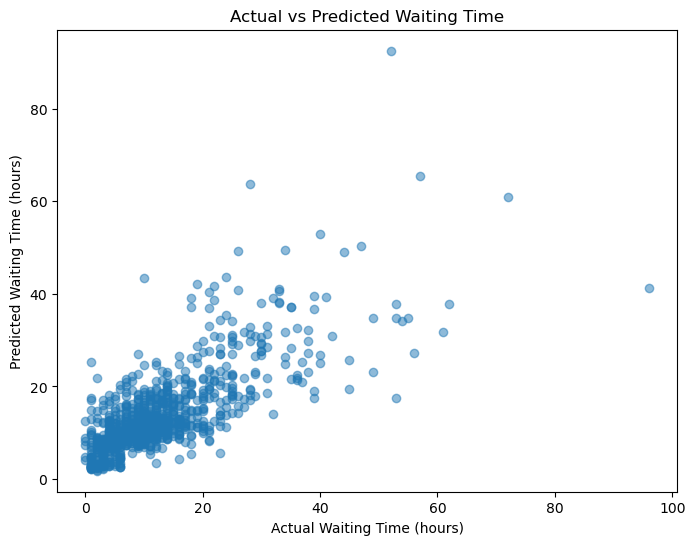

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Waiting Time (hours)")
plt.ylabel("Predicted Waiting Time (hours)")
plt.title("Actual vs Predicted Waiting Time")

plt.show()

## Feature Importance

Random Forest can estimate the relative importance of each input feature.

Feature importance helps us understand which variables contributed most
to the model's predictions.

We will inspect the most important features before improving the model.

In [55]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("Top 15 important features:")
print(importance_df.head(15).to_string(index=False))

Top 15 important features:
                               Feature  Importance
               numerical__waiting_lag1    0.462588
                numerical__waiting_ma4    0.235347
                numerical__waiting_ma8    0.046035
               numerical__waiting_lag2    0.026246
               numerical__waiting_ma12    0.024398
  numerical__count_entrance_neopanamax    0.021047
               numerical__waiting_lag4    0.019316
       numerical__numofcall_neopanamax    0.017969
                  numerical__numofcall    0.016762
               numerical__share_neopan    0.015685
              numerical__waiting_lag12    0.013991
     numerical__numofcall_intermediate    0.013880
                       numerical__Week    0.013255
             numerical__count_entrance    0.012407
numerical__count_entrance_intermediate    0.012202


In [56]:
baseline_pred = test["waiting_lag1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Naive Baseline Evaluation")
print("-------------------------")
print(f"MAE  : {baseline_mae:.2f} hours")
print(f"RMSE : {baseline_rmse:.2f} hours")
print(f"R²   : {baseline_r2:.4f}")

Naive Baseline Evaluation
-------------------------
MAE  : 4.36 hours
RMSE : 6.72 hours
R²   : 0.5598


## Next-Week Waiting Time Target

For a realistic forecasting problem, the model should predict the next
week's waiting time using information available from the current week
and earlier.

For each port:

Target at Week T = waiting time at Week T+1

This prevents the model from using future waiting-time information when
making a prediction.

In [57]:
adb = adb.sort_values(["Port", "Year", "Week"]).copy()

adb["next_week_waiting_time"] = (
    adb.groupby("Port")["avgwaiting_time"].shift(-1)
)

print(adb[[
    "Port",
    "Year",
    "Week",
    "avgwaiting_time",
    "next_week_waiting_time"
]].head(15))

       Port    Year  Week  avgwaiting_time  next_week_waiting_time
12  Antwerp  2019.0  13.0              7.0                     3.0
13  Antwerp  2019.0  14.0              3.0                     6.0
14  Antwerp  2019.0  15.0              6.0                    10.0
15  Antwerp  2019.0  16.0             10.0                    10.0
16  Antwerp  2019.0  17.0             10.0                     7.0
17  Antwerp  2019.0  18.0              7.0                     8.0
18  Antwerp  2019.0  19.0              8.0                     5.0
19  Antwerp  2019.0  20.0              5.0                     4.0
20  Antwerp  2019.0  21.0              4.0                     5.0
21  Antwerp  2019.0  22.0              5.0                     7.0
22  Antwerp  2019.0  23.0              7.0                     7.0
23  Antwerp  2019.0  24.0              7.0                     5.0
24  Antwerp  2019.0  25.0              5.0                     9.0
25  Antwerp  2019.0  26.0              9.0                    